In [12]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
def read_collision_data_complete(filename):
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    sections = {}
    data_rows = []
    similarity_values = []
    snp_rate = []

    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        if line.startswith(':1:'):
            sections['test_name'] = line[3:].strip()
        elif line.startswith(':2:'):
            sections['column_headers'] = line[3:].strip().split(',')
        elif line.startswith(':3:'):
            line_content = line[3:].strip()
            line_parts = line_content.split(',')
            sections['Hashname'] = line_parts[0].strip()
            sections['SequenceLength'] = int(line_parts[1].strip())
            sections['TokenLength'] = int(line_parts[2].strip())
            sections['Distance_Metric'] = int(line_parts[3].strip())
        elif line.startswith(':4:'):
            line_content = line[3:].strip()
            similarity_values = [float(x.strip()) for x in line_content.split(',')]
            sections['similarity_values'] = similarity_values
        elif line.startswith(':5:'):
            line_content = line[3:].strip()
            snp_rate = [float(x.strip()) for x in line_content.split(',')]
            sections['snp_rate'] = snp_rate
        elif line.startswith(':6:'):
            line_content = line[3:].strip()
            collision_rates = [float(x.strip()) for x in line_content.split(',')]
            sections['collision_rates'] = collision_rates
            
            # Create data row
            row_data = {
                'test_name': sections.get('test_name', ''),
                'hashname': sections.get('Hashname', ''),
                'sequencelength': sections.get('SequenceLength', 0),
                'tokenlength': sections.get('TokenLength', 0),
                'similarity_values': similarity_values,
                'snp_rate': snp_rate,
                'collision_rates': collision_rates
            }
            data_rows.append(row_data)
    
    return sections, pd.DataFrame(data_rows)


In [14]:
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_OneBaseSamplingHash-32.csv")
sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_MinHash-32.csv")

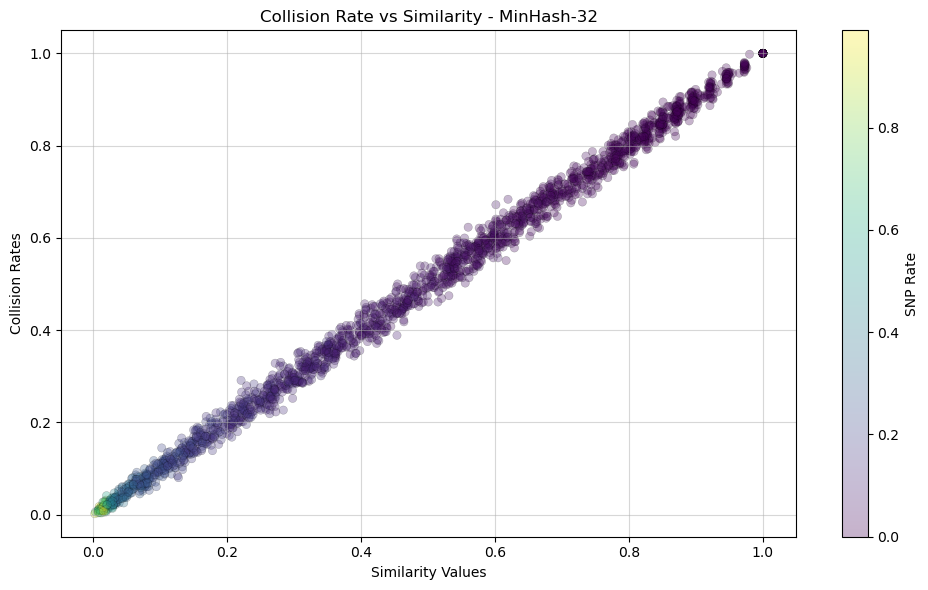

In [15]:
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
    
    plt.figure(figsize=(10, 6))
    plt.grid(True, alpha=0.5)
    plt.scatter(x_values, y_values, c=label_values, cmap='viridis', alpha=0.3, edgecolors='black', linewidth=0.3)
    plt.colorbar(label='SNP Rate')
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {row['hashname']}")
    
    
    plt.tight_layout()
    plt.show()

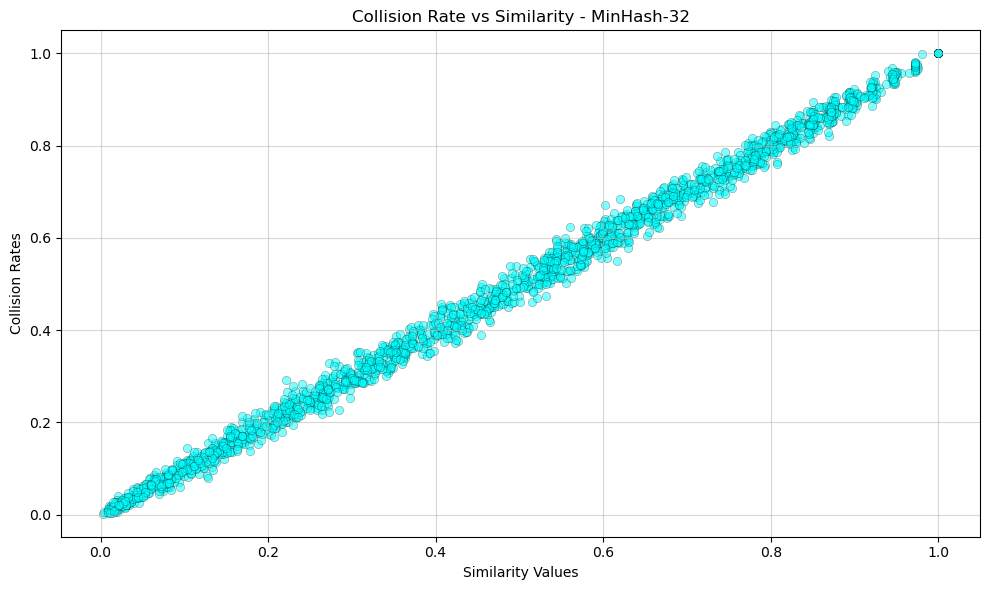

In [16]:
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
	
	#TODO: Labels to be derived from hashname, token size if token size is not 0, then the sequence length and distance metric
    plt.figure(figsize=(10, 6))
    plt.grid(True, alpha=0.5)
    plt.scatter(x_values, y_values, alpha=0.5, color='cyan', edgecolors='black', linewidth=0.3)
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {row['hashname']}")
    
    
    plt.tight_layout()
    plt.show()